In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


We do the same calculations that we did in "btc_std_calc_2_states.ipynb". Refer to that.

In [2]:
# Refer to "8_states_transitions_and_means.ipynb" for this.
P = np.genfromtxt("mat_8_states.csv",delimiter=",")

In [3]:
P

array([[0.153773, 0.083944, 0.136944, 0.253664, 0.172774, 0.080619,
        0.040309, 0.077972],
       [0.102519, 0.083847, 0.150872, 0.304562, 0.205654, 0.081469,
        0.033468, 0.037608],
       [0.076394, 0.064391, 0.132418, 0.320744, 0.271053, 0.091485,
        0.021542, 0.021972],
       [0.036488, 0.033224, 0.077365, 0.373853, 0.406126, 0.048982,
        0.012635, 0.011327],
       [0.012599, 0.012933, 0.046113, 0.363634, 0.418997, 0.083134,
        0.031453, 0.031138],
       [0.022718, 0.020936, 0.081332, 0.234419, 0.365752, 0.14325 ,
        0.063885, 0.067709],
       [0.033975, 0.033108, 0.067949, 0.173774, 0.332033, 0.172907,
        0.091437, 0.094817],
       [0.076037, 0.034398, 0.068796, 0.14295 , 0.267289, 0.158375,
        0.093852, 0.158303]])

$$\pi = [0.002312, 0.008625, 0.039261, 0.424289, 0.476712, 0.038519,
       0.008175, 0.002106]

In [4]:
pi = np.genfromtxt("pi_8_states.csv",delimiter=",")

In [5]:
pi

array([0.036979, 0.030335, 0.07385 , 0.333538, 0.375693, 0.082681,
       0.031614, 0.035308])

In [6]:
Pi = np.vstack([pi]*8)

Took $$ a(4) = 20, a(3) =15,...  a(-4) = -20. \implies a^* =  0.243817$$

In [7]:
# Refer to "8_states_transitions_and_means.ipynb" for this.
a_star = -0.596376

In [8]:
a = np.array([-20,-15,-10,-5,5,10,15,20])

In [9]:
b = np.array(a-a_star)

In [10]:
b

array([-19.403624, -14.403624,  -9.403624,  -4.403624,   5.596376,
        10.596376,  15.596376,  20.596376])

$$ g:= (P + \Pi^* -I){^-1} b$$

In [11]:
A= np.linalg.inv(P + Pi - np.eye(8))

In [12]:
print(A)

[[-1.07804566 -0.01281192  0.05708453  0.79097791  1.03041806  0.15630193
   0.04649952  0.00957542]
 [-0.01634946 -1.00854329  0.04784581  0.71768191  0.97425068  0.16327441
   0.05966436  0.06217547]
 [ 0.01969697  0.01671245 -0.9258645   0.68798454  0.88693217  0.15688207
   0.07425115  0.08340523]
 [ 0.07593923  0.0579444   0.14480484 -0.39125101  0.71282608  0.20830781
   0.08827147  0.10315854]
 [ 0.10683809  0.08322791  0.18286668  0.6279652  -0.3108774   0.16722371
   0.06472664  0.0780317 ]
 [ 0.08947517  0.07176393  0.14154937  0.79334219  0.7690676  -0.91144937
   0.0209476   0.02530595]
 [ 0.07388392  0.05791326  0.15256259  0.87732936  0.8179207   0.04767701
  -1.01428934 -0.01299607]
 [ 0.01938578  0.05126448  0.14548598  0.93335588  0.90999669  0.05414504
  -0.0233409  -1.09029169]]


In [13]:
g = np.matmul(A,b)


In [14]:
print(g)

[ 25.42784377  20.62711932  14.55582581   7.75108411  -5.10791196
 -12.10061232 -18.57016116 -23.74645871]


In [15]:
v = np.zeros(len(g))

In [16]:
for i in range(len(v)):
    s = 0
    for j in range(len(v)):
        s += ((g[j]-g[i])**2)* P[i,j]
    s_2=0
    for j in range(len(v)):
        s_2 += (g[j]-g[i])*P[i,j]
    v[i] = b[i]**2 + s - 2*(b[i])*s_2

In [17]:
print(v)

[227.90431087 174.50488893 146.93896678  99.78767421  97.3980864
 140.7280309  165.78600398 223.28349033]


$$\sigma ^2 = \sum \pi _i v(i) $$

In [18]:
sigma = np.sqrt(np.matmul(pi,v))

In [19]:
print(sigma)

10.918235622040033


$$ \sigma = 7.169038526159254$$

But we need $$\sigma \sqrt{(\frac{\lambda }{1-\hat{h}})}$$

We have $$\lambda = 0.00031458686590702084, a =  0.02230285826488395, b =  0.04458713874443153$$

In [20]:
lamb = 0.16508945342301887

a=0.011477956127453995

b = 0.20470834799305934

We have $$h(t,z) = z a \exp(-bt)$$

$$H(z):= \int _0 ^ \infty h(t,z) dt$$ 

Thus in our case we have $$H(z) = \frac{az}{b}$$

Now we take the density of Z as $f(z)$

An observation before gave us $$f(z) = \frac{1}{\sqrt{2 \pi \sigma ^2}} \exp({-1/2 \frac{(z-\mu)^2}{\sigma ^2} })$$

When we fitted , got $$\mu = 13.329567797401769,$$

In [21]:
mu = 13.329567797401769


$$\hat{h} := \int{H(z)f(z)} dz$$

In [22]:
h_hat = a/b * mu

In [23]:
print(h_hat)

0.7473862003013596


In [24]:
par =  (sigma * np.sqrt(lamb/(1-h_hat)))

In [25]:
print(par)

8.826399723480758


In [26]:
data_interval =  np.linspace(0, +1200, 100)

In [27]:
std_results = np.genfromtxt("std_results.csv",delimiter=",")
x = std_results[:,0]
y = std_results[:,1]



Regression coefficients (fitted on n >= 200):
Model: y = 12.787256 + 7.123004 * sqrt(x)
Intercept: 12.787256
Slope (C): 7.123004


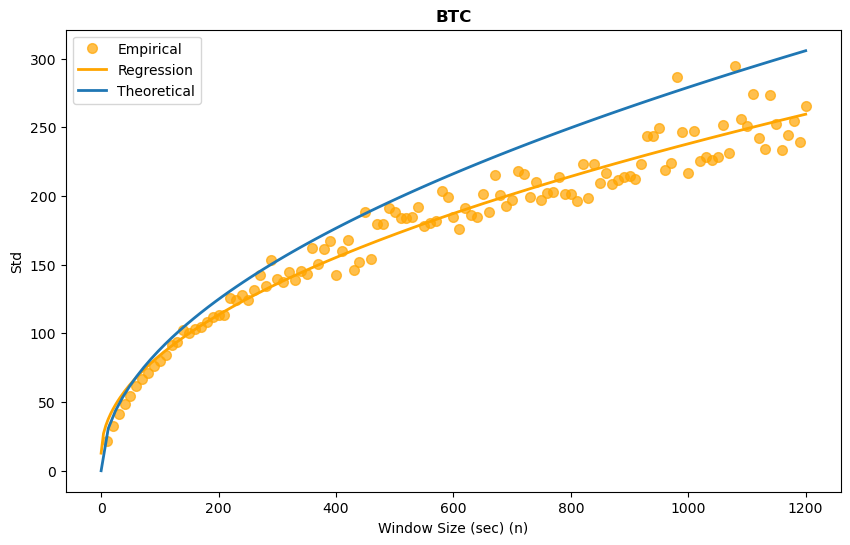

In [28]:
# Add regression line: y = C * sqrt(x), starting from n=200
plt.figure(figsize=(10,6))

"""# Filter data for n >= 200
mask = x >= 200
x_filtered = x[mask]
y_filtered = y[mask]"""

# Fit model: std = C * sqrt(window_size) using only n >= 200
# Transform x to sqrt(x) and fit linear regression
x_sqrt_filtered = np.sqrt(x)
# Fit y = C * sqrt(x) (linear regression in transformed space)
coeffs = np.polyfit(x_sqrt_filtered, y, 1) 

# Print coefficients
print(f"\nRegression coefficients (fitted on n >= 200):")
print(f"Model: y = {coeffs[1]:.6f} + {coeffs[0]:.6f} * sqrt(x)")
print(f"Intercept: {coeffs[1]:.6f}")
print(f"Slope (C): {coeffs[0]:.6f}")

plt.plot(
    x, 
    y, 
    'o',
    color="orange",
    label='Empirical',
    alpha=0.7,
    markersize=7
)



# Create smooth line for plotting, starting from n=200
x_smooth = np.linspace(0, x.max(), 300)
x_smooth_sqrt = np.sqrt(x_smooth)
regression_line = np.polyval(coeffs, x_smooth_sqrt)
plt.plot(x_smooth, regression_line, '-', label='Regression', color="orange", linewidth=2)

plt.plot(data_interval,np.sqrt(data_interval)*par,label = "Theoretical",linewidth = 2 )




plt.title("BTC", fontweight='bold')
plt.xlabel('Window Size (sec) (n)')
plt.ylabel('Std')
plt.legend()

plt.show()

In [29]:
y_hat = np.sqrt(x)*par

In [30]:
MSE = np.array([(y[i]-y_hat[i])**2   for i in range(len(y_hat))])

In [31]:
MSE = np.sum(MSE) / len(MSE)

In [ ]:
print(f"Mean Square Error: {MSE}")

1063.8146961094885


In [35]:
print(f"Percentage error:%{((par-7.123004)/par)*100}")

Percentage error:%19.29887357071804
